In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/clean/ticket_dataset.csv")

In [2]:
df.head()

,ticket_id,ticket,category,priority,ticket_length
0,1,I would like a second delivery try. I first no...,Delivery,Medium,105
1,2,I was charged in the wrong currency. I first n...,Billing,Low,88
2,3,"Dear support, I got a message saying my accoun...",Account,High,135
3,4,"Hey, I want a refund please. I have contacted ...",Refund,Medium,119
4,5,"Good morning, Delivery was promised for Monday...",Delivery,Medium,147


In [3]:
df["category"].value_counts()

category
Refund       239
Technical    214
Delivery     193
Billing      184
Account      170
Name: count, dtype: int64

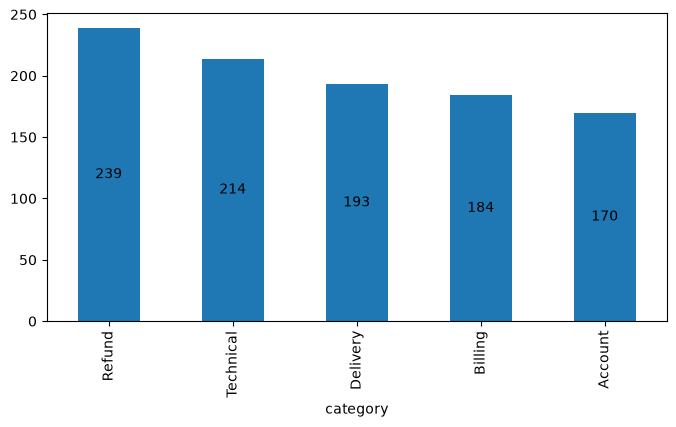

In [4]:
category_count = df["category"].value_counts()

bar = category_count.plot(kind="bar", figsize=(8,4))
for container in bar.containers:
    bar.bar_label(container, label_type="center")

In [5]:
# It is clear that Technical is the most common category

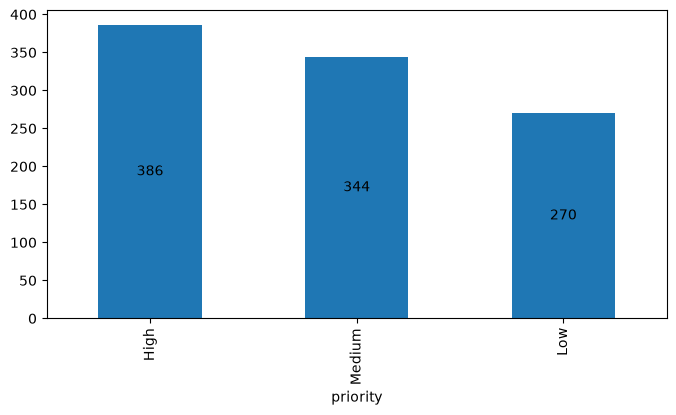

In [6]:
priority_count = df["priority"].value_counts()

bar = priority_count.plot(kind="bar", figsize=(8,4))
for container in bar.containers:
    bar.bar_label(container, label_type="center")

In [7]:
pd.crosstab(df["category"], df["priority"])

priority,High,Low,Medium
category,,,
Account,68,43,59
Billing,62,63,59
Delivery,63,65,65
Refund,96,67,76
Technical,97,32,85


In [8]:
# Once again, you can cleary see that the Technical category has the most "high priority" tickets per category

In [9]:
import sqlite3
link = sqlite3.connect(":memory:")
df.to_sql("tickets", link, index=False, if_exists="replace")

1000

In [10]:
query = """
SELECT category, COUNT(*) AS ticket_count
FROM tickets
GROUP BY category
"""

pd.read_sql_query(query, link)

,category,ticket_count
0,Account,170
1,Billing,184
2,Delivery,193
3,Refund,239
4,Technical,214


In [11]:
query = """
SELECT category, AVG(ticket_length) AS average_length
FROM tickets
GROUP BY category
ORDER by average_length DESC;
"""

pd.read_sql_query(query, link)

,category,average_length
0,Account,118.270588
1,Delivery,114.585492
2,Technical,113.490654
3,Refund,110.125523
4,Billing,109.413043


In [12]:
query = """
SELECT category, ticket, priority
FROM tickets
WHERE priority ="High";
"""

pd.read_sql_query(query, link)

,category,ticket,priority
0,Account,"Dear support, I got a message saying my accoun...",High
1,Account,I cannot log in and now my payment will not go...,High
2,Technical,"Dear support, Settings screen makes the whole ...",High
3,Refund,"Good morning, Charged after cancelling, please...",High
4,Technical,Wishlist is empty after I logged in on another...,High
...,...,...,...
381,Account,"Good morning, My past orders are missing from ...",High
382,Billing,"hey, duplicate payment taken for one purchase....",High
383,Account,The authenticator code is always rejected. I o...,High
384,Technical,"Hi team, Nothing happens when I tap Pay now. L...",High


In [13]:
from sklearn.model_selection import train_test_split
# using 80/20 train test split in order for there to be unseen test cases for the model

In [14]:
X = df["ticket"]
y = df["category"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state=11)

In [15]:
# going to use Term Frequency to convert the "language" to singular values i.e payment, account ETC

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english"  # removes words like "I" and "and" 
    , max_features=5000  # gets a maximum of 5000 key words
)
                                                                   
X_train_tfidf = vectorizer.fit_transform(X_train) #learns vocab from training
X_test_tfidf = vectorizer.transform(X_test) #converts the test data

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000) # an empty model goes through 1000 to get the best solution

model.fit(X_train_tfidf, y_train) # training the model to see words like "payment" and associate it with the "Billing" category 


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [17]:
y_pred = model.predict(X_test_tfidf) # making a prediction

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred) # seeing the accuracy of the model
print("Accuracy of model is at:", accuracy * 100, "%")

Accuracy of model is at: 76.5 %


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Account       0.78      0.74      0.76        38
     Billing       0.76      0.74      0.75        35
    Delivery       0.76      0.71      0.73        41
      Refund       0.75      0.83      0.78        46
   Technical       0.78      0.80      0.79        40

    accuracy                           0.77       200
   macro avg       0.77      0.76      0.76       200
weighted avg       0.77      0.77      0.76       200



In [20]:
# the precision is the true positives / false positives and true positives  (TP/FP + TP)
# the recall is the true positives / total in such relevant category (TP / Total)
# the f1 score is 2 x (precision * recall) / (precision + recall)

In [21]:
#now creating a proirity model

In [22]:
X = df["ticket"]
y = df["priority"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.2, random_state=11)

In [23]:
vectorizer = TfidfVectorizer(
     max_features=10000,
     stop_words= "english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [24]:

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [25]:
y_pred = model.predict(X_test_tfidf)

In [26]:
accuracy = accuracy_score(y_test, y_pred) # seeing the accuracy of the model
print("Accuracy of model is at:", accuracy * 100, "%")

Accuracy of model is at: 61.5 %


In [27]:
# it is clear that the priority model has found it difficult to frequently correcty predict the priority of a test ticket
# this suggest that the priority of a ticket may be subjective

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.61      0.76      0.68        72
         Low       0.71      0.59      0.65        54
      Medium       0.55      0.49      0.52        74

    accuracy                           0.61       200
   macro avg       0.63      0.61      0.61       200
weighted avg       0.62      0.61      0.61       200



In [29]:
# from the classification report, it is clear that the medium priority is the cause of most problems, but why?
# it has a low precision rate, meaning that out of all the times the model predicts the ticket to be "medium" priority, its only 55% right.
# in addition to this, it has a low recall rate, meaning that it only actually finds roughly 50% of the "medium" priority tickets.

In [ ]:
# i will now attempt to improve the models methods of training instead of changing the dataset